<a href="https://colab.research.google.com/github/eomoran/derivative-securities-project/blob/feature%2Fimplied-vol/ImpliedVolatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#How to run this jupyternotebook



*   Step One: Download 'MS_All_Call_Options.csv', 'MS_All_Put_Options.csv', 'MS_Stock_Prices.csv', 'RFR_DS.csv' from the shared folder to your computer
*   Step Two: create a 'derivative_securities' folder under your own Google Drive.
*   Step Three: Upload 'MS_All_Call_Options.csv', 'MS_All_Put_Options.csv', 'MS_Stock_Prices.csv', 'RFR_DS.csv' to 'derivative_securities' folder under your own Google Drive.
*   Step Four: Now you may execute the following code. The output of Calculated_IV would also be saved to your own Google Drive. The rationale being that Google Colab does not allow me to mount files from a shared folder that does not belong to me.



In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# %cd /content/drive/MyDrive/derivative_securities/
%cd /content/drive/MyDrive/DS Group Project/Q2 Implied Volatility #This might work for everyone?

/content/drive/MyDrive/DS Group Project/Q2 Implied Volatility


In [14]:
!ls

 calculated_ivs_calls.xlsx   DGS1MO_DS.gsheet	       RFR_DS.csv
 calculated_ivs_puts.xlsx    ImpliedVolatility.ipynb  'Risk Free Rate.xlsx'
 calculated_ivs.xlsx	     MS_All_Call_Options.csv   SOFR_DS.csv
'DGS1MO_DS (1).gsheet'	     MS_All_Put_Options.csv
 DGS1MO_DS.csv		     MS_Stock_Prices.csv


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import io
import re

# Suppress specific runtime warnings that might occur during optimization
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [16]:
# ======================================================================
# 0. Data Loading Utilities (Handling specific CSV formats)
# ======================================================================

def load_options_data(filename, option_type):
    """
    Loads and preprocesses the option CSV files.
    This version finds the correct header row (starting with "Ticker")
    and skips any metadata lines before it.
    """
    try:
        with open(filename, 'r') as f:
            # Read all lines into a list
            lines = f.readlines()

        # 1. Find the header row
        # We'll search for the line that starts with "Ticker" (case-insensitive, ignoring spaces)
        header_row_index = -1
        for i, line in enumerate(lines):
            if line.strip().lower().startswith('ticker'):
                header_row_index = i
                break

        if header_row_index == -1:
            print(f"ERROR: Could not find header row (starting with 'Ticker') in {filename}")
            return pd.DataFrame()

        # 2. Re-join the *correct* lines (from the header row onwards)
        # This effectively skips the metadata lines like "Puts,,,,,,"
        correct_csv_content = "".join(lines[header_row_index:])

        # 3. Read into pandas
        # We use io.StringIO to treat the string as a file
        df = pd.read_csv(io.StringIO(correct_csv_content))
        df['Type'] = option_type
        return df

    except FileNotFoundError:
        print(f"ERROR: File not found: {filename}")
        print("Please ensure the CSV files are in the correct directory.")
        return pd.DataFrame()
    except Exception as e:
        print(f"An unexpected error occurred processing {filename}: {e}")
        return pd.DataFrame()

def load_stock_data(filename):
    """Loads stock data, skipping the initial metadata rows."""
    try:
        # Stock price file has 6 rows of metadata before the headers
        df = pd.read_csv(filename, skiprows=6)
        # Clean up potential empty rows resulting from trailing commas/empty lines in the file
        df = df.dropna(subset=['Date', 'PX_ADJ_CLOSE'])
        # Convert Date column to datetime objects (Format: M/D/YY)
        df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y', errors='coerce')
        return df
    except FileNotFoundError:
        print(f"ERROR: File not found: {filename}")
        return pd.DataFrame()

# def load_rfr_data(filename, rf_series):
#     """
#     Loads RFR data and calculates the continuously compounded rate.
#     """
#     try:
#         df = pd.read_csv(filename)

#         # Clean up potential empty rows
#         df = df.dropna(subset=['Effective Date', rf_series])

#         # Convert Date column to datetime objects
#         df['Effective Date'] = pd.to_datetime(df['Effective Date'], format='%m/%d/%Y', errors='coerce')

#         # --- CORRECTION START ---
#         # 1. Convert percentage to decimal (e.g., 5.25 -> 0.0525)
#         simple_rate = df[rf_series] / 100.0

#         # 2. Convert simple annualized rate to continuously compounded rate
#         # Formula: r_continuous = ln(1 + r_simple)
#         df['r_continuous'] = np.log(1 + simple_rate)
#         # --- CORRECTION END ---

#         return df
#     except FileNotFoundError:
#         print(f"ERROR: File not found: {filename}")
#         return pd.DataFrame()

def load_rfr_data(filename, rf_series):
    """Loads RFR data."""
    try:
        df = pd.read_csv(filename)
        # Clean up potential empty rows
        df = df.dropna(subset=['Effective Date', rf_series])
        # Convert Date column to datetime objects (Format: MM/DD/YYYY)
        df['Effective Date'] = pd.to_datetime(df['Effective Date'], format='%m/%d/%Y', errors='coerce')
        return df
    except FileNotFoundError:
        print(f"ERROR: File not found: {filename}")
        return pd.DataFrame()


# ======================================================================
# 1. Helper Functions (BSM Model and IV Solver)
# ======================================================================

def bsm_price(S, K, T, r, sigma, option_type='call'):
    """Calculates the Black-Scholes-Merton price for a European option."""
    # Handle edge cases where T or sigma are effectively zero
    if T <= 1e-9:
        if option_type == 'call':
            return max(0.0, S - K)
        else:
            return max(0.0, K - S)

    if sigma <= 1e-5:
        # Price is discounted intrinsic value when sigma is zero
        if option_type == 'call':
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price

def implied_volatility(market_price, S, K, T, r, option_type='call', tolerance=1e-6):
    """Calculates the Implied Volatility using the Brent method (root-finding)."""

    def objective_function(sigma):
        return bsm_price(S, K, T, r, sigma, option_type) - market_price

    # Check for intrinsic value violations (simple arbitrage check)
    if T > 0:
        if option_type == 'call':
            intrinsic = max(0, S - K * np.exp(-r*T))
        else:
            intrinsic = max(0, K * np.exp(-r*T) - S)

        # If market price is below intrinsic value, IV cannot be solved reliably
        if market_price < intrinsic - tolerance:
           return np.nan

    # Use brentq (robust root finder) to find the volatility in the range [0.001% to 500%]
    try:
        iv = brentq(objective_function, a=1e-5, b=5.0, xtol=tolerance)
        return iv
    except ValueError:
        # Root not found in the range (e.g., price violates bounds)
        return np.nan

In [19]:
# ======================================================================
# 2. Data Loading
# ======================================================================
RF_SERIES = 'DGS1MO' # or # SOFR
print("Loading data files...")
df_calls = load_options_data('MS_All_Call_Options.csv', 'call')
df_puts = load_options_data('MS_All_Put_Options.csv', 'put')
df_stock = load_stock_data('MS_Stock_Prices.csv')
df_rfr = load_rfr_data(filename='RFR_DS.csv', rf_series=RF_SERIES)

# Check if dataframes loaded correctly
if df_calls.empty or df_puts.empty or df_stock.empty or df_rfr.empty:
    print("Stopping execution due to data loading errors.")
    # In a notebook, execution stops if we don't proceed. We use a flag to control the flow.
    DATA_LOADED = False
else:
    df_options = pd.concat([df_calls, df_puts], ignore_index=True)
    print("Data loaded and parsed successfully.")
    DATA_LOADED = True

Loading data files...
Data loaded and parsed successfully.


In [21]:
# ======================================================================
# 3. Data Preparation and Parameter Extraction
# ======================================================================

if DATA_LOADED:
    # Define key dates (using datetime objects for comparison with pandas dataframes)
    TRADE_DATE_DT = pd.to_datetime(datetime.date(2025, 9, 19))
    EXPIRY_DATE_DT = pd.to_datetime(datetime.date(2025, 10, 17))

    # 3.1. Time to Expiry (T) - Actual/365 convention
    T = (EXPIRY_DATE_DT - TRADE_DATE_DT).days / 365.0

    # 3.2. Spot Price (S)
    try:
        S = df_stock[df_stock['Date'] == TRADE_DATE_DT]['PX_ADJ_CLOSE'].iloc[0]
    except IndexError:
        print(f"ERROR: Could not find Spot Price for Trade Date {TRADE_DATE_DT.date()}")
        S = np.nan

    # 3.3. Risk-Free Rate (r)
    try:
      # TODO update rate to rate_name_param
        # r = df_rfr[df_rfr['Effective Date'] == TRADE_DATE_DT][RF_SERIES].iloc[0] / 100.0
        # r = df_rfr[df_rfr['Effective Date'] == TRADE_DATE_DT]['r_continuous'].iloc[0] / 100.0
        r_simple = df_rfr[df_rfr['Effective Date'] == TRADE_DATE_DT][RF_SERIES].iloc[0] / 100.0
        r = np.log(1 + r_simple)

    except IndexError:
        print(f"ERROR: Could not find RFR Rate for Trade Date {TRADE_DATE_DT.date()}")
        r = np.nan

    if np.isnan(S) or np.isnan(r):
        print("Stopping execution due to missing parameters.")
        PARAMETERS_VALID = False
    else:
        PARAMETERS_VALID = True
        print(f"\nParameters on Trade Date ({TRADE_DATE_DT.date()}):")
        print(f"Spot Price (S): {S:.2f}")
        print(f"Risk-Free Rate (r): {r:.4f} ({r*100:.2f}%)")
        print(f"Risk-Free Series (RF_SERIES): {RF_SERIES}")
        print(f"Time to Expiry (T): {T:.4f} years ({(EXPIRY_DATE_DT - TRADE_DATE_DT).days} days)\n")

        # 3.4. Process Option Chain Data

        # Ensure numeric types
        numeric_cols = ['Strike', 'Bid', 'Ask', 'Last', 'IVM', 'Volm']
        for col in numeric_cols:
            df_options[col] = pd.to_numeric(df_options[col], errors='coerce')

        # Calculate Mid Price (Market Price)
        df_options['Mid'] = (df_options['Bid'] + df_options['Ask']) / 2.0

        # Filtering: Remove illiquid options (Bid/Ask near zero)
        MIN_PRICE = 0.01
        df_options_filtered = df_options[
            (df_options['Bid'] > MIN_PRICE) &
            (df_options['Ask'] > MIN_PRICE) &
            (df_options['Strike'] > 0)
        ].copy()

        # Drop rows where essential data might be missing after conversion
        df_options_filtered = df_options_filtered.dropna(subset=['Strike', 'Mid'])
else:
    print("Skipping parameter preparation because data failed to load.")
    PARAMETERS_VALID = False


Parameters on Trade Date (2025-09-19):
Spot Price (S): 159.91
Risk-Free Rate (r): 0.0410 (4.10%)
Risk-Free Series (RF_SERIES): DGS1MO
Time to Expiry (T): 0.0767 years (28 days)



In [22]:
# ======================================================================
# 4. Calculate Implied Volatility
# ======================================================================

if PARAMETERS_VALID:
    print(f"Calculating IVs for {len(df_options_filtered)} liquid options...")

    # Apply the IV solver
    df_options_filtered['Calculated_IV'] = df_options_filtered.apply(
        lambda row: implied_volatility(
            market_price=row['Mid'],
            S=S,
            K=row['Strike'],
            T=T,
            r=r,
            option_type=row['Type']
        ),
        axis=1
    )

    # Remove rows where IV could not be calculated (e.g. intrinsic value violations)
    df_iv = df_options_filtered.dropna(subset=['Calculated_IV'])

    print(f"Successfully calculated IVs for {len(df_iv)} options.\n")

    # Separate back into Calls and Puts for plotting
    df_iv_calls = df_iv[df_iv['Type'] == 'call'].sort_values(by='Strike')
    df_iv_puts = df_iv[df_iv['Type'] == 'put'].sort_values(by='Strike')

else:
    print("Skipping IV calculation because parameters are invalid or data failed to load.")

Calculating IVs for 46 liquid options...
Successfully calculated IVs for 45 options.



In [23]:
if 'df_iv' in locals():
    # Define the filenames
    calls_filename = 'calculated_ivs_calls.xlsx'
    puts_filename = 'calculated_ivs_puts.xlsx'

    # Separate the dataframes
    df_iv_calls = df_iv[df_iv['Type'] == 'call'].copy()
    df_iv_puts = df_iv[df_iv['Type'] == 'put'].copy()

    # Save the calls dataframe
    df_iv_calls.to_excel(calls_filename, index=False, engine='openpyxl')

    # Save the puts dataframe
    df_iv_puts.to_excel(puts_filename, index=False, engine='openpyxl')

    print(f"Successfully saved data to:")
    print(f"  - '{calls_filename}' ({len(df_iv_calls)} rows)")
    print(f"  - '{puts_filename}' ({len(df_iv_puts)} rows)")
    print("You can download them from the 'Files' panel on the left.")
else:
    print("Skipping save: 'df_iv' dataframe not found. Did you run Cell 5?")

Successfully saved data to:
  - 'calculated_ivs_calls.xlsx' (29 rows)
  - 'calculated_ivs_puts.xlsx' (16 rows)
You can download them from the 'Files' panel on the left.


## Important Note:
### The Calculated_IV (what we use BSM to solve) and the IV supplied from Bloomberg are in DIFFERENT scale. The IV from Bloomberg are expressed in PERCENTAGE whereas our Calculated_IV are in DECIMALS, so the difference in maginitude is just due to difference in scale.

## Graph Visualizations and Analysis:
### The '5. Visualization' and '6. Analysis of Consistency ' here are also done in Excel so that it could be exported to Powerpoint, here the work is just to get a quick intuition of it

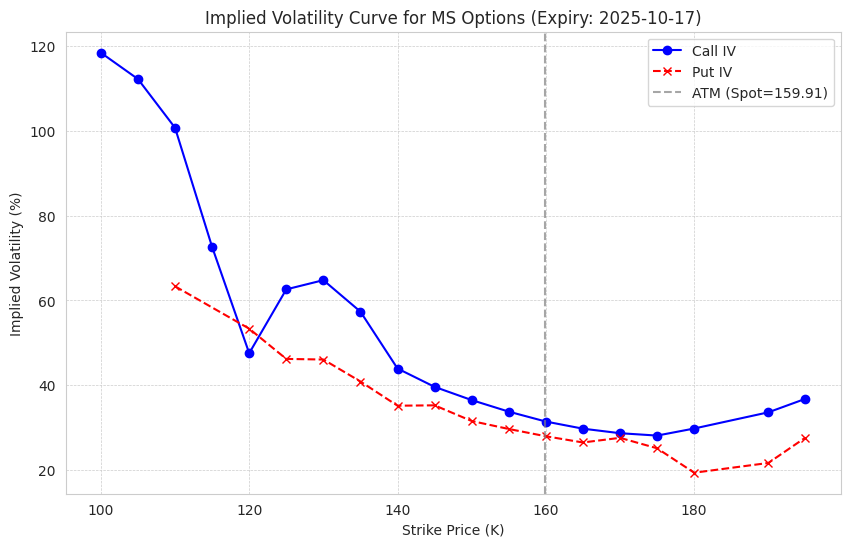

In [24]:
# ======================================================================
# 5. Visualization (Task 2 Requirement)
# ======================================================================

if PARAMETERS_VALID and 'df_iv' in locals():
    # Filter data for visualization to focus near the money (+/- 40%) for clarity
    # Deep ITM/OTM options often have unreliable IVs due to low liquidity.
    moneyness_filter = (df_iv['Strike'] >= S * 0.6) & (df_iv['Strike'] <= S * 1.4)
    df_iv_plot = df_iv[moneyness_filter]

    df_iv_calls_plot = df_iv_plot[df_iv_plot['Type'] == 'call'].sort_values(by='Strike')
    df_iv_puts_plot = df_iv_plot[df_iv_plot['Type'] == 'put'].sort_values(by='Strike')


    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    # Plot Calls IV (as percentage)
    plt.plot(df_iv_calls_plot['Strike'], df_iv_calls_plot['Calculated_IV'] * 100,
             marker='o', linestyle='-', color='blue', label='Call IV')

    # Plot Puts IV
    plt.plot(df_iv_puts_plot['Strike'], df_iv_puts_plot['Calculated_IV'] * 100,
             marker='x', linestyle='--', color='red', label='Put IV')

    # Add ATM line
    plt.axvline(S, color='grey', linestyle='--', alpha=0.7, label=f'ATM (Spot={S:.2f})')

    plt.title(f'Implied Volatility Curve for MS Options (Expiry: {EXPIRY_DATE_DT.date()})')
    plt.xlabel('Strike Price (K)')
    plt.ylabel('Implied Volatility (%)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

else:
    print("Skipping visualization because calculations were not performed.")

In [25]:
# ======================================================================
# 6. Analysis of Consistency (Task 2 Requirement)
# ======================================================================
if PARAMETERS_VALID and 'df_iv_calls' in locals():
    # Merge Calls and Puts IVs on Strike price to compare them side-by-side
    df_comparison = pd.merge(
        df_iv_calls[['Strike', 'Calculated_IV']],
        df_iv_puts[['Strike', 'Calculated_IV']],
        on='Strike',
        how='inner', # Only include strikes where both Call and Put exist and have valid IV
        suffixes=('_Call', '_Put')
    )

    if not df_comparison.empty:
        df_comparison['IV_Difference'] = df_comparison['Calculated_IV_Call'] - df_comparison['Calculated_IV_Put']

        # Format for better display
        df_comparison_formatted = df_comparison.copy()
        df_comparison_formatted['Calculated_IV_Call'] = (df_comparison_formatted['Calculated_IV_Call'] * 100).map('{:.2f}%'.format)
        df_comparison_formatted['Calculated_IV_Put'] = (df_comparison_formatted['Calculated_IV_Put'] * 100).map('{:.2f}%'.format)
        df_comparison_formatted['IV_Difference'] = (df_comparison_formatted['IV_Difference'] * 100).map('{:.2f}%'.format)

        print("\nComparison of Call and Put Implied Volatilities:")
        # Display the comparison table (using Markdown for nice formatting in Jupyter/Colab)
        try:
            from IPython.display import display, Markdown
            display(Markdown(df_comparison_formatted.to_markdown(index=False)))
        except ImportError:
            # Fallback for non-Jupyter environments
            print(df_comparison_formatted.to_string(index=False))

        avg_diff = df_comparison['IV_Difference'].mean() * 100
        print(f"\nAverage Difference (Call IV - Put IV) across all common liquid strikes: {avg_diff:.2f}%")

    else:
        print("\nNo common strikes found between liquid Calls and Puts for comparison.")
else:
    print("Skipping consistency analysis because calculations were not performed.")


Comparison of Call and Put Implied Volatilities:


|   Strike | Calculated_IV_Call   | Calculated_IV_Put   | IV_Difference   |
|---------:|:---------------------|:--------------------|:----------------|
|      110 | 100.75%              | 63.33%              | 37.42%          |
|      120 | 47.54%               | 53.33%              | -5.79%          |
|      125 | 62.61%               | 46.19%              | 16.42%          |
|      130 | 64.78%               | 46.05%              | 18.73%          |
|      135 | 57.35%               | 40.86%              | 16.49%          |
|      140 | 43.92%               | 35.15%              | 8.77%           |
|      145 | 39.60%               | 35.24%              | 4.36%           |
|      150 | 36.48%               | 31.54%              | 4.94%           |
|      155 | 33.75%               | 29.66%              | 4.09%           |
|      160 | 31.41%               | 27.94%              | 3.47%           |
|      165 | 29.73%               | 26.47%              | 3.26%           |
|      170 | 28.66%               | 27.57%              | 1.09%           |
|      175 | 28.10%               | 25.10%              | 3.00%           |
|      180 | 29.77%               | 19.33%              | 10.43%          |
|      190 | 33.59%               | 21.64%              | 11.95%          |
|      195 | 36.78%               | 27.63%              | 9.15%           |


Average Difference (Call IV - Put IV) across all common liquid strikes: 9.24%
